In [1]:
!pip install -q transformers datasets evaluate scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.0 MB/s eta 0:00:00


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

In [4]:
print("GPU Available:", torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

GPU Available: True
GPU Name: Tesla T4


In [5]:
import random
import pandas as pd

positive_reviews = [
    "Excellent product quality and fast delivery.",
    "I am very satisfied with this purchase.",
    "Amazing product, highly recommended.",
    "The product works exactly as described.",
    "Great value for money.",
    "Packaging was neat and secure.",
    "Customer support was very helpful.",
    "Five stars, will buy again.",
    "The quality exceeded my expectations.",
    "Very durable and easy to use.",
]

negative_reviews = [
    "Very poor quality and disappointing.",
    "The product stopped working after two days.",
    "Waste of money.",
    "Delivery was delayed and packaging was damaged.",
    "The item was not as described.",
    "Customer support did not respond.",
    "I am unhappy with this purchase.",
    "Terrible experience overall.",
    "The product is defective.",
    "Not worth the price.",
]

modifiers = [
    "I bought this for personal use.",
    "My family liked it.",
    "Would definitely recommend it.",
    "I expected better.",
    "The delivery was on time.",
    "The design is attractive.",
    "Performance is impressive.",
    "I will not buy this again.",
]

reviews = []

for _ in range(500):
    if random.random() > 0.5:
        review = random.choice(positive_reviews)
        label = 1
    else:
        review = random.choice(negative_reviews)
        label = 0

    if random.random() > 0.5:
        review += " " + random.choice(modifiers)

    reviews.append({
        "review": review,
        "label": label
    })

reviews_df = pd.DataFrame(reviews)
reviews_df.head()

,review,label
0,Great value for money. I bought this for perso...,1
1,I am unhappy with this purchase.,0
2,Great value for money.,1
3,Not worth the price.,0
4,"Five stars, will buy again.",1


In [8]:
from datasets import Dataset

# Convert pandas DataFrame to Hugging Face Dataset
dataset = Dataset.from_pandas(reviews_df)

# Train-test split (without stratification)
dataset = dataset.train_test_split(
    test_size=0.2,
    seed=42,
)

train_dataset = dataset["train"]
test_dataset = dataset["test"]

print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))

# Check class balance
print("\nTraining label distribution:")
print(pd.Series(train_dataset["label"]).value_counts())

print("\nTesting label distribution:")
print(pd.Series(test_dataset["label"]).value_counts())

# Preview one example
train_dataset[0]

Training samples: 400
Testing samples: 100

Training label distribution:
0    220
1    180
Name: count, dtype: int64

Testing label distribution:
1    53
0    47
Name: count, dtype: int64


{'review': 'Terrible experience overall. I will not buy this again.',
 'label': 0}

In [9]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_NAME = "distilbert-base-uncased"

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Load model for binary classification
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

print("DistilBERT model and tokenizer loaded successfully!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT model and tokenizer loaded successfully!


In [10]:
def tokenize_function(examples):
    return tokenizer(
        examples["review"],
        truncation=True,
        padding="max_length",
        max_length=128,
    )

train_dataset = train_dataset.map(
    tokenize_function,
    batched=True
)

test_dataset = test_dataset.map(
    tokenize_function,
    batched=True
)

print("Tokenization completed successfully!")

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Tokenization completed successfully!


In [11]:
# ============================================================
# STEP 8: PREPARE DATASET FOR PYTORCH
# ============================================================

# Keep only the required columns
train_dataset = train_dataset.remove_columns(["review"])
test_dataset = test_dataset.remove_columns(["review"])

# Rename label column to labels (required by Hugging Face Trainer)
train_dataset = train_dataset.rename_column("label", "labels")
test_dataset = test_dataset.rename_column("label", "labels")

# Convert to PyTorch tensors
train_dataset.set_format("torch")
test_dataset.set_format("torch")

print("Dataset prepared for training!")
print("Training features:", train_dataset.column_names)
print("Testing features:", test_dataset.column_names)

Dataset prepared for training!
Training features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask']
Testing features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask']


In [12]:
# ============================================================
# STEP 9: DEFINE EVALUATION METRICS
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary"
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

print("Evaluation metrics function created successfully!")

Evaluation metrics function created successfully!


In [13]:
# ============================================================
# STEP 10: DEFINE TRAINING ARGUMENTS
# ============================================================

from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./sentiment_results",

    # Training configuration
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,

    # Evaluation and saving
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=20,

    # Load best model
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    # Misc
    seed=42,
    report_to="none",
)

print("Training arguments configured successfully!")

Training arguments configured successfully!


In [14]:
# ============================================================
# STEP 11: CREATE TRAINER
# ============================================================

from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

print("Trainer created successfully!")

Trainer created successfully!


In [15]:
# ============================================================
# STEP 12: TRAIN THE MODEL
# ============================================================

train_results = trainer.train()

print("Training completed successfully!")

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.598031,0.327224,1.000000,1.000000,1.000000,1.000000
2,0.277925,0.140645,1.000000,1.000000,1.000000,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Training completed successfully!


In [17]:
# Evaluate the model
eval_results = trainer.evaluate()

# Display evaluation metrics
pd.DataFrame(eval_results.items(), columns=["Metric", "Value"])

,Metric,Value
0,eval_loss,0.327203
1,eval_accuracy,1.000000
2,eval_precision,1.000000
3,eval_recall,1.000000
4,eval_f1,1.000000
5,eval_runtime,0.442200
6,eval_samples_per_second,226.126000
7,eval_steps_per_second,15.829000
8,epoch,2.000000


In [18]:
# Extract log history
log_history = trainer.state.log_history

# Keep only rows that contain training loss
loss_rows = [x for x in log_history if "loss" in x]

loss_df = pd.DataFrame(loss_rows)

loss_df.head()

,loss,grad_norm,learning_rate,epoch,step
0,0.598031,2.266641,0.000012,0.8,20
1,0.277925,1.572688,0.000004,1.6,40


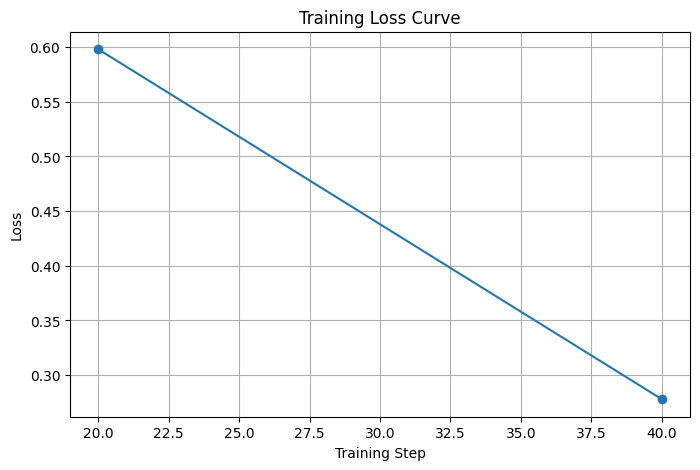

In [19]:
# Plot training loss curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(loss_df["step"], loss_df["loss"], marker="o")
plt.title("Training Loss Curve")
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

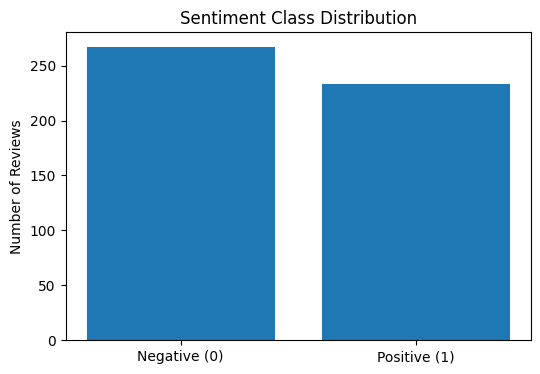

In [20]:
# Plot sentiment label distribution
label_counts = reviews_df["label"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["Negative (0)", "Positive (1)"], label_counts.values)
plt.title("Sentiment Class Distribution")
plt.ylabel("Number of Reviews")
plt.show()

In [22]:
# ============================================================
# STEP 16: INTERACTIVE SENTIMENT PREDICTION FUNCTION
# ============================================================

import torch

def predict_sentiment(review):
    # Tokenize input text
    inputs = tokenizer(
        review,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128,
    )

    # Move tensors to the same device as the model
    device = model.device
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # Inference
    with torch.no_grad():
        outputs = model(**inputs)

    # Convert logits to probabilities
    probabilities = torch.softmax(outputs.logits, dim=1)

    # Predicted class
    predicted_class = torch.argmax(probabilities, dim=1).item()

    # Confidence score
    confidence = probabilities[0][predicted_class].item()

    # Labels
    sentiment = "Positive 😊" if predicted_class == 1 else "Negative 😞"

    return {
        "review": review,
        "sentiment": sentiment,
        "confidence": confidence,
    }


# ============================================================
# TEST ON SAMPLE REVIEWS
# ============================================================

sample_reviews = [
    "This product is amazing and exceeded my expectations.",
    "Very poor quality and not worth the money.",
    "Delivery was quick and the packaging was excellent.",
    "The item stopped working after two days.",
    "Customer support was extremely helpful and polite.",
]

for review in sample_reviews:
    result = predict_sentiment(review)

    print("=" * 80)
    print("Review:", result["review"])
    print("Predicted Sentiment:", result["sentiment"])
    print(f"Confidence: {result['confidence']:.4f}")

Review: This product is amazing and exceeded my expectations.
Predicted Sentiment: Positive 😊
Confidence: 0.7009
Review: Very poor quality and not worth the money.
Predicted Sentiment: Negative 😞
Confidence: 0.6836
Review: Delivery was quick and the packaging was excellent.
Predicted Sentiment: Positive 😊
Confidence: 0.7469
Review: The item stopped working after two days.
Predicted Sentiment: Negative 😞
Confidence: 0.7943
Review: Customer support was extremely helpful and polite.
Predicted Sentiment: Positive 😊
Confidence: 0.7308


In [25]:
# ============================================================
# STEP 17: INTERACTIVE SENTIMENT ANALYSIS CONSOLE
# ============================================================

print("🎯 Customer Review Sentiment Analyzer is Ready!")
print("Type a product review and press Enter.")
print("Type 'exit' to stop.\n")

while True:
    user_review = input("Enter a customer review: ")

    if user_review.lower().strip() in ["exit", "quit", "q"]:
        print("\nThank you for using the Sentiment Analyzer! 👋")
        break

    if not user_review.strip():
        print("Please enter a valid review.\n")
        continue

    result = predict_sentiment(user_review)

    print("\n" + "=" * 80)
    print("📝 Review:")
    print(result["review"])
    print("\n📊 Predicted Sentiment:")
    print(result["sentiment"])
    print(f"\n🎯 Confidence Score: {result['confidence']:.4f}")
    print("=" * 80 + "\n")

🎯 Customer Review Sentiment Analyzer is Ready!
Type a product review and press Enter.
Type 'exit' to stop.

Enter a customer review: The battery drains quickly and the device becomes hot within minutes.

📝 Review:
The battery drains quickly and the device becomes hot within minutes.

📊 Predicted Sentiment:
Negative 😞

🎯 Confidence Score: 0.5759

Enter a customer review: The packaging was elegant and the product is absolutely worth the price.

📝 Review:
The packaging was elegant and the product is absolutely worth the price.

📊 Predicted Sentiment:
Positive 😊

🎯 Confidence Score: 0.7272

Enter a customer review: I had high expectations, but the overall experience was disappointing.

📝 Review:
I had high expectations, but the overall experience was disappointing.

📊 Predicted Sentiment:
Negative 😞

🎯 Confidence Score: 0.6851

Enter a customer review: q

Thank you for using the Sentiment Analyzer! 👋


In [26]:
def predict_with_visualization(review):
    inputs = tokenizer(
        review,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128,
    )

    device = model.device
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    probs = torch.softmax(outputs.logits, dim=1).cpu().numpy()[0]

    labels = ["Negative 😞", "Positive 😊"]

    # Print prediction
    predicted_idx = probs.argmax()
    print("Review:", review)
    print("Predicted Sentiment:", labels[predicted_idx])
    print(f"Confidence: {probs[predicted_idx]:.4f}")

    # Plot probabilities
    plt.figure(figsize=(6, 4))
    plt.bar(labels, probs)
    plt.ylim(0, 1)
    plt.ylabel("Probability")
    plt.title("Sentiment Prediction Probabilities")
    plt.show()

Review: The product looked good initially, but it broke after just one use.
Predicted Sentiment: Negative 😞
Confidence: 0.6534


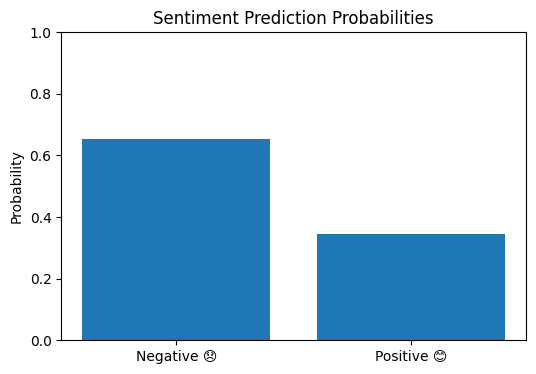

In [27]:
predict_with_visualization(
    "The product looked good initially, but it broke after just one use."
)

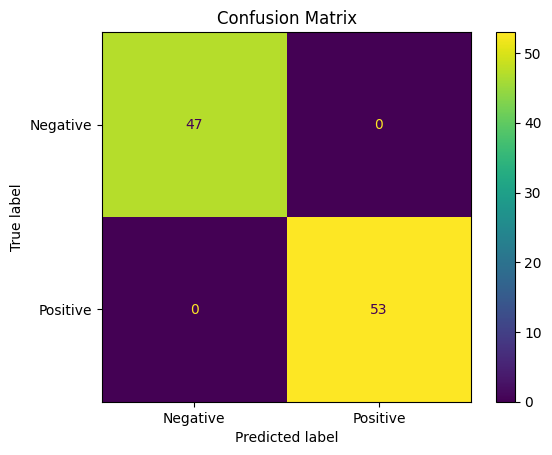

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

predictions = trainer.predict(test_dataset)
y_pred = predictions.predictions.argmax(axis=1)
y_true = predictions.label_ids

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [29]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Negative", "Positive"]
    )
)

              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        47
    Positive       1.00      1.00      1.00        53

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



In [30]:
example_reviews = [
    "The product quality is excellent.",
    "The item stopped working after two days.",
    "Packaging was good and delivery was quick.",
    "Very disappointed with this purchase.",
]

results = []

for review in example_reviews:
    pred = predict_sentiment(review)
    results.append({
        "Review": review,
        "Sentiment": pred["sentiment"],
        "Confidence": round(pred["confidence"], 4),
    })

pd.DataFrame(results)

,Review,Sentiment,Confidence
0,The product quality is excellent.,Positive 😊,0.6672
1,The item stopped working after two days.,Negative 😞,0.7943
2,Packaging was good and delivery was quick.,Positive 😊,0.7702
3,Very disappointed with this purchase.,Negative 😞,0.6470


In [31]:
project_summary = {
    "Notebook": "03_bert_customer_review_sentiment_analysis.ipynb",
    "Model": "DistilBERT (BERT family)",
    "Task": "Customer Review Sentiment Classification",
    "Dataset Size": len(reviews_df),
    "Training Samples": len(train_dataset),
    "Testing Samples": len(test_dataset),
    "Epochs": 2,
    "Final Accuracy": eval_results["eval_accuracy"],
    "Final F1 Score": eval_results["eval_f1"],
    "Framework": "Hugging Face Transformers",
}

pd.DataFrame(
    project_summary.items(),
    columns=["Parameter", "Value"]
)

,Parameter,Value
0,Notebook,03_bert_customer_review_sentiment_analysis.ipynb
1,Model,DistilBERT (BERT family)
2,Task,Customer Review Sentiment Classification
3,Dataset Size,500
4,Training Samples,400
5,Testing Samples,100
6,Epochs,2
7,Final Accuracy,1.0
8,Final F1 Score,1.0
9,Framework,Hugging Face Transformers
